<a href="https://colab.research.google.com/github/otikuoY/texas-education-opportunity-data-analysis/blob/version-2-tea-public-school-outcomes/notebooks/02_public_school_outcomes_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Version 2: Public School Outcomes and Private School Access

This notebook expands the original Texas private-school access project by adding public-school outcome data from the Texas Academic Performance Reports (TAPR).

The goal is to examine whether private-school access is related to public-school outcomes, after also considering county-level income, poverty, population, and adult education level.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

base = "/content/drive/MyDrive/nyu-data-project"

print("Setup complete.")

Mounted at /content/drive
Setup complete.


In [2]:
raw_path = base + "/data/raw"

for file in os.listdir(raw_path):
    if file.startswith("tea_"):
        print(file)

tea_district_reference_raw.csv
tea_student_information_raw.csv
tea_attendance_raw.csv
tea_ccmr_raw.csv
tea_graduation_raw.csv


In [3]:
tea_ref = pd.read_csv(base + "/data/raw/tea_district_reference_raw.csv", low_memory=False)
tea_student = pd.read_csv(base + "/data/raw/tea_student_information_raw.csv", low_memory=False)
tea_attendance = pd.read_csv(base + "/data/raw/tea_attendance_raw.csv", low_memory=False)
tea_ccmr = pd.read_csv(base + "/data/raw/tea_ccmr_raw.csv", low_memory=False)
tea_graduation = pd.read_csv(base + "/data/raw/tea_graduation_raw.csv", low_memory=False)

print("District reference:", tea_ref.shape)
print("Student information:", tea_student.shape)
print("Attendance:", tea_attendance.shape)
print("CCMR:", tea_ccmr.shape)
print("Graduation:", tea_graduation.shape)

District reference: (1209, 12)
Student information: (1209, 242)
Attendance: (1209, 164)
CCMR: (1209, 277)
Graduation: (1209, 226)


In [7]:
# Inspect District Reference columns

district_ref_cols = pd.DataFrame({
    "index": range(len(tea_ref.columns)),
    "column": tea_ref.columns
})

district_ref_cols[
    district_ref_cols["column"].str.contains(
        "district|county|region|name|number|id|campus",
        case=False,
        regex=True
    )
].head(50)

,index,column
0,0,6 Digit County District Number
1,1,District Name
2,2,3 Digit County Number
3,3,County Name
4,4,2 Digit ESC Region
5,5,Region Name
6,6,District 2025 Flag - Charter Operator (Y/N)
7,7,District Rated Under AEA Procedures Flag
8,8,2025 District Overall Grade
9,9,2025 District Post Secondary Distinction


In [8]:
# Clean district reference data

tea_ref_clean = tea_ref[[
    "6 Digit County District Number",
    "District Name",
    "3 Digit County Number",
    "County Name"
]].copy()

tea_ref_clean = tea_ref_clean.rename(columns={
    "6 Digit County District Number": "district_id",
    "District Name": "district_name",
    "3 Digit County Number": "county_number",
    "County Name": "county"
})

tea_ref_clean["district_id"] = tea_ref_clean["district_id"].astype(str).str.zfill(6)

tea_ref_clean["county"] = (
    tea_ref_clean["county"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Clean district reference shape:", tea_ref_clean.shape)

tea_ref_clean.head()

Clean district reference shape: (1209, 4)


,district_id,district_name,county_number,county
0,DISTRICT,DISTNAME,COUNTY,cntyname
1,001902,CAYUGA ISD,001,anderson
2,001903,ELKHART ISD,001,anderson
3,001904,FRANKSTON ISD,001,anderson
4,001906,NECHES ISD,001,anderson


In [9]:
# Remove non-data header row from district reference

tea_ref_clean = tea_ref_clean[
    tea_ref_clean["district_id"].astype(str).str.isnumeric()
].copy()

tea_ref_clean["district_id"] = tea_ref_clean["district_id"].astype(str).str.zfill(6)

tea_ref_clean["county"] = (
    tea_ref_clean["county"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Clean district reference shape after removing header row:", tea_ref_clean.shape)

tea_ref_clean.head()

Clean district reference shape after removing header row: (1208, 4)


,district_id,district_name,county_number,county
1,001902,CAYUGA ISD,001,anderson
2,001903,ELKHART ISD,001,anderson
3,001904,FRANKSTON ISD,001,anderson
4,001906,NECHES ISD,001,anderson
5,001907,PALESTINE ISD,001,anderson


In [10]:
# Inspect Student Information columns

student_cols = pd.DataFrame({
    "index": range(len(tea_student.columns)),
    "column": tea_student.columns
})

student_cols[
    student_cols["column"].str.contains(
        "district|econ|disadv|student|enroll|total",
        case=False,
        regex=True
    )
].head(80)

,index,column
0,0,6 Digit County District Number
1,1,District Name
2,2,District 2025 Class Size: Sec Soc Stud- Avg Size
3,3,District 2025 Class Size: Sec Sci - Avg Size
4,4,District 2025 Class Size: Sec Math - Avg Size
...,...,...
75,75,District 2024 Retention: Regular Ed 04 Rate
76,76,District 2024 Retention: Regular Ed 05 Rate
77,77,District 2024 Retention: Regular Ed 06 Rate
78,78,District 2024 Retention: Regular Ed 07 Rate


In [11]:
# Find economically disadvantaged columns only

econ_cols = pd.DataFrame({
    "index": range(len(tea_student.columns)),
    "column": tea_student.columns
})

econ_cols[
    econ_cols["column"].str.contains(
        "econ|disadv|eco dis|economically",
        case=False,
        regex=True
    )
].to_string(index=False)

' index                                                               column\n    34                  District 2025 Student Membership: Econ Disadv Count\n    35     District 2025 Student Membership: Non-Educationally Disadv Count\n    99                District 2025 Student Membership: Econ Disadv Percent\n   100   District 2025 Student Membership: Non-Educationally Disadv Percent\n   190   District 2025 Student Enrollment: Economically Disadvantaged Count\n   191 District 2025 Student Enrollment: Economically Disadvantaged Percent\n   192     District 2025 Student Enrollment: Non-Educationally Disadv Count\n   193   District 2025 Student Enrollment: Non-Educationally Disadv Percent\n   228    District 2025 Student Membership: 2024 Mobility Econ Disadv Count\n   239  District 2025 Student Membership: 2024 Mobility Econ Disadv Percent'

In [12]:
# Clean student information data: economically disadvantaged percentage

district_col = "6 Digit County District Number"

econ_col = [
    col for col in tea_student.columns
    if "Student Membership" in col
    and "Econ Disadv Percent" in col
    and "Mobility" not in col
][0]

print("Using district column:", district_col)
print("Using econ disadvantaged column:", econ_col)

tea_student_clean = tea_student[[district_col, econ_col]].copy()

tea_student_clean = tea_student_clean.rename(columns={
    district_col: "district_id",
    econ_col: "econ_disadv_pct"
})

# Remove non-data header row
tea_student_clean = tea_student_clean[
    tea_student_clean["district_id"].astype(str).str.isnumeric()
].copy()

tea_student_clean["district_id"] = (
    tea_student_clean["district_id"]
    .astype(str)
    .str.zfill(6)
)

tea_student_clean["econ_disadv_pct"] = (
    tea_student_clean["econ_disadv_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

tea_student_clean["econ_disadv_pct"] = pd.to_numeric(
    tea_student_clean["econ_disadv_pct"],
    errors="coerce"
)

print("Student clean shape:", tea_student_clean.shape)

tea_student_clean.head()

Using district column: 6 Digit County District Number
Using econ disadvantaged column: District 2025 Student Membership: Econ Disadv Percent
Student clean shape: (1208, 2)


,district_id,econ_disadv_pct
1,001902,45.9
2,001903,51.7
3,001904,50.4
4,001906,49.0
5,001907,80.7


In [13]:
# Inspect Attendance columns

attendance_cols = pd.DataFrame({
    "index": range(len(tea_attendance.columns)),
    "column": tea_attendance.columns
})

attendance_cols[
    attendance_cols["column"].str.contains(
        "attendance|absentee|chronic|all students|rate|district",
        case=False,
        regex=True
    )
].head(120)

,index,column
0,0,6 Digit County District Number
1,1,District Name
2,2,District 2024 Attendance: All Students Days Pr...
3,3,District 2024 Attendance: Two or More Races Da...
4,4,District 2024 Attendance: Asian Days Present
...,...,...
115,115,"Annual Dropout Rate, Grades 07-08, SY 2023-24,..."
116,116,"Annual Dropout Rate, Grades 07-08, SY 2023-24,..."
117,117,"Annual Dropout Rate, Grades 07-08, SY 2023-24,..."
118,118,"Annual Dropout Rate, Grades 07-08, SY 2023-24,..."


In [14]:
# Show full attendance-related column names

pd.set_option("display.max_colwidth", None)

attendance_matches = attendance_cols[
    attendance_cols["column"].str.contains(
        "attendance|chronic|absentee",
        case=False,
        regex=True
    )
]

attendance_matches.to_string(index=False)

' index                                                                 column\n     2                    District 2024 Attendance: All Students Days Present\n     3               District 2024 Attendance: Two or More Races Days Present\n     4                           District 2024 Attendance: Asian Days Present\n     5                District 2024 Attendance: Pacific Islander Days Present\n     6                District 2024 Attendance: African American Days Present\n     7                        District 2024 Attendance: Hispanic Days Present\n     8                           District 2024 Attendance: White Days Present\n     9                 District 2024 Attendance: American Indian Days Present\n    10                     District 2024 Attendance: Econ Disadv Days Present\n    11                      District 2024 Attendance: Special Ed Days Present\n    12                          District 2024 Attendance: Female Days Present\n    13                            District 2024 Att

In [15]:
# Print full attendance column names line by line

for i, col in enumerate(tea_attendance.columns):
    col_text = str(col)
    if "Attendance" in col_text and "All Students" in col_text:
        print(i, col_text)

2 District 2024 Attendance: All Students Days Present
16 District 2024 Attendance: All Students Days Membership
30 District 2024 Attendance: All Students Rate


In [16]:
# Print chronic absenteeism columns

for i, col in enumerate(tea_attendance.columns):
    col_text = str(col)
    if "Chronic" in col_text or "Absentee" in col_text:
        print(i, col_text)

44 2024 district Chronic Absenteeism All Students Group: Numerator
45 2024 district Chronic Absenteeism All Students Group: Denominator
46 2024 district Chronic Absenteeism African American Group: Numerator
47 2024 district Chronic Absenteeism African American Group: Denominator
48 2024 district Chronic Absenteeism Hispanic Group: Numerator
49 2024 district Chronic Absenteeism Hispanic Group: Denominator
50 2024 district Chronic Absenteeism White Group: Numerator
51 2024 district Chronic Absenteeism White Group: Denominator
52 2024 district Chronic Absenteeism American Indian Group: Numerator
53 2024 district Chronic Absenteeism American Indian Group: Denominator
54 2024 district Chronic Absenteeism Asian Group: Numerator
55 2024 district Chronic Absenteeism Asian Group: Denominator
56 2024 district Chronic Absenteeism Pacific Islander Group: Numerator
57 2024 district Chronic Absenteeism Pacific Islander Group: Denominator
58 2024 district Chronic Absenteeism Two or More Races Group: 

In [18]:
# Clean attendance data using automatic column search

district_col = "6 Digit County District Number"

attendance_col = [
    col for col in tea_attendance.columns
    if "Attendance" in str(col)
    and "All Students" in str(col)
    and "Rate" in str(col)
][0]

chronic_col = [
    col for col in tea_attendance.columns
    if "Chronic Absenteeism" in str(col)
    and "All Students" in str(col)
    and "Rate" in str(col)
][0]

print("Using district column:", district_col)
print("Using attendance column:", attendance_col)
print("Using chronic absenteeism column:", chronic_col)

tea_attendance_clean = tea_attendance[[
    district_col,
    attendance_col,
    chronic_col
]].copy()

tea_attendance_clean = tea_attendance_clean.rename(columns={
    district_col: "district_id",
    attendance_col: "attendance_rate",
    chronic_col: "chronic_absenteeism_rate"
})

# Remove non-data header row
tea_attendance_clean = tea_attendance_clean[
    tea_attendance_clean["district_id"].astype(str).str.isnumeric()
].copy()

tea_attendance_clean["district_id"] = (
    tea_attendance_clean["district_id"]
    .astype(str)
    .str.zfill(6)
)

for col in ["attendance_rate", "chronic_absenteeism_rate"]:
    tea_attendance_clean[col] = (
        tea_attendance_clean[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    tea_attendance_clean[col] = pd.to_numeric(
        tea_attendance_clean[col],
        errors="coerce"
    )

print("Attendance clean shape:", tea_attendance_clean.shape)

tea_attendance_clean.head()

Using district column: 6 Digit County District Number
Using attendance column: District 2024 Attendance: All Students Rate
Using chronic absenteeism column: 2024 district Chronic Absenteeism All Students Group: Rate
Attendance clean shape: (1208, 3)


,district_id,attendance_rate,chronic_absenteeism_rate
1,001902,94.9,11.5
2,001903,95.8,7.2
3,001904,95.3,11.4
4,001906,96.1,5.4
5,001907,95.2,12.1


In [19]:
# Inspect CCMR columns

for i, col in enumerate(tea_ccmr.columns):
    col_text = str(col)
    if (
        "CCMR" in col_text
        or "College" in col_text
        or "Career" in col_text
        or "Military" in col_text
        or "Annual Graduates" in col_text
    ):
        print(i, col_text)

2 District 2024 College, Career, & Military Ready Graduates: All Students Numerator
3 District 2024 College, Career, & Military Ready Graduates: All Students Denominator
4 District 2024 College, Career, & Military Ready Graduates: African American Numerator
5 District 2024 College, Career, & Military Ready Graduates: African American Denominator
6 District 2024 College, Career, & Military Ready Graduates: Hispanic Numerator
7 District 2024 College, Career, & Military Ready Graduates: Hispanic Denominator
8 District 2024 College, Career, & Military Ready Graduates: White Numerator
9 District 2024 College, Career, & Military Ready Graduates: White Denominator
10 District 2024 College, Career, & Military Ready Graduates: American Indian Numerator
11 District 2024 College, Career, & Military Ready Graduates: American Indian Denominator
12 District 2024 College, Career, & Military Ready Graduates: Asian Numerator
13 District 2024 College, Career, & Military Ready Graduates: Asian Denominato

In [20]:
# Find all-students CCMR rate columns only

for i, col in enumerate(tea_ccmr.columns):
    col_text = str(col)
    if (
        "Associated CCMR" in col_text
        and "All Students" in col_text
        and "Rate" in col_text
    ):
        print(i, col_text)

101 District 2024 Associated CCMR: College Ready - All Students Rate
102 District 2024 Associated CCMR: College Ready Only - All Students Rate
103 District 2024 Associated CCMR: Career/Military Ready Only - All Students Rate
104 District 2024 Associated CCMR: College Ready and Career/Military Ready - All Students Rate
105 District 2024 Associated CCMR: Associate Degree and Career/Military Ready - All Students Rate
106 District 2024 Associated CCMR: Associate Degree but not Career/Military Ready - All Students Rate


In [21]:
# Clean CCMR data

district_col = "6 Digit County District Number"

ccmr_col = "District 2024 Associated CCMR: College Ready and Career/Military Ready - All Students Rate"

tea_ccmr_clean = tea_ccmr[[
    district_col,
    ccmr_col
]].copy()

tea_ccmr_clean = tea_ccmr_clean.rename(columns={
    district_col: "district_id",
    ccmr_col: "ccmr_rate"
})

# Remove non-data header row
tea_ccmr_clean = tea_ccmr_clean[
    tea_ccmr_clean["district_id"].astype(str).str.isnumeric()
].copy()

tea_ccmr_clean["district_id"] = (
    tea_ccmr_clean["district_id"]
    .astype(str)
    .str.zfill(6)
)

tea_ccmr_clean["ccmr_rate"] = (
    tea_ccmr_clean["ccmr_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
)

tea_ccmr_clean["ccmr_rate"] = pd.to_numeric(
    tea_ccmr_clean["ccmr_rate"],
    errors="coerce"
)

print("CCMR clean shape:", tea_ccmr_clean.shape)

tea_ccmr_clean.head()

CCMR clean shape: (1208, 2)


,district_id,ccmr_rate
1,001902,82.4
2,001903,29.0
3,001904,84.1
4,001906,36.8
5,001907,36.6


In [22]:
# Find all-students graduation rate columns

for i, col in enumerate(tea_graduation.columns):
    col_text = str(col)
    if (
        "Longitudinal" in col_text
        and "4-Year" in col_text
        and "Class of 2024" in col_text
        and "Graduates" in col_text
        and "All Students" in col_text
        and "Rate" in col_text
    ):
        print(i, col_text)

128 Longitudinal, 4-Year, Class of 2024, Graduates, All Students, Rate
212 Longitudinal, 4-Year, Class of 2024, Graduates, All Students, Rate.1


In [23]:
# Clean graduation data

district_col = "6 Digit County District Number"
graduation_col = "Longitudinal, 4-Year, Class of 2024, Graduates, All Students, Rate"

tea_graduation_clean = tea_graduation[[
    district_col,
    graduation_col
]].copy()

tea_graduation_clean = tea_graduation_clean.rename(columns={
    district_col: "district_id",
    graduation_col: "graduation_rate"
})

# Remove non-data header row
tea_graduation_clean = tea_graduation_clean[
    tea_graduation_clean["district_id"].astype(str).str.isnumeric()
].copy()

tea_graduation_clean["district_id"] = (
    tea_graduation_clean["district_id"]
    .astype(str)
    .str.zfill(6)
)

tea_graduation_clean["graduation_rate"] = (
    tea_graduation_clean["graduation_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
)

tea_graduation_clean["graduation_rate"] = pd.to_numeric(
    tea_graduation_clean["graduation_rate"],
    errors="coerce"
)

print("Graduation clean shape:", tea_graduation_clean.shape)

tea_graduation_clean.head()

Graduation clean shape: (1208, 2)


,district_id,graduation_rate
1,001902,92.1
2,001903,100.0
3,001904,97.8
4,001906,95.0
5,001907,98.3


In [24]:
# Merge all TEA district-level data

tea_district = tea_ref_clean.merge(
    tea_student_clean,
    on="district_id",
    how="left"
).merge(
    tea_attendance_clean,
    on="district_id",
    how="left"
).merge(
    tea_ccmr_clean,
    on="district_id",
    how="left"
).merge(
    tea_graduation_clean,
    on="district_id",
    how="left"
)

print("Merged TEA district dataset shape:", tea_district.shape)

tea_district.head()

Merged TEA district dataset shape: (1208, 9)


,district_id,district_name,county_number,county,econ_disadv_pct,attendance_rate,chronic_absenteeism_rate,ccmr_rate,graduation_rate
0,001902,CAYUGA ISD,001,anderson,45.9,94.9,11.5,82.4,92.1
1,001903,ELKHART ISD,001,anderson,51.7,95.8,7.2,29.0,100.0
2,001904,FRANKSTON ISD,001,anderson,50.4,95.3,11.4,84.1,97.8
3,001906,NECHES ISD,001,anderson,49.0,96.1,5.4,36.8,95.0
4,001907,PALESTINE ISD,001,anderson,80.7,95.2,12.1,36.6,98.3


In [25]:
# Find total student membership column

for i, col in enumerate(tea_student.columns):
    col_text = str(col)
    if (
        "Student Membership" in col_text
        and "All Students" in col_text
        and "Count" in col_text
        and "Mobility" not in col_text
    ):
        print(i, col_text)

29 District 2025 Student Membership: All Students Count
58 District 2025 Student Membership: 2023-24 Attrition All Students Count


In [26]:
# Add student count to TEA district dataset

district_col = "6 Digit County District Number"
student_count_col = "District 2025 Student Membership: All Students Count"

tea_enrollment_clean = tea_student[[
    district_col,
    student_count_col
]].copy()

tea_enrollment_clean = tea_enrollment_clean.rename(columns={
    district_col: "district_id",
    student_count_col: "student_count"
})

# Remove non-data header row
tea_enrollment_clean = tea_enrollment_clean[
    tea_enrollment_clean["district_id"].astype(str).str.isnumeric()
].copy()

tea_enrollment_clean["district_id"] = (
    tea_enrollment_clean["district_id"]
    .astype(str)
    .str.zfill(6)
)

tea_enrollment_clean["student_count"] = (
    tea_enrollment_clean["student_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

tea_enrollment_clean["student_count"] = pd.to_numeric(
    tea_enrollment_clean["student_count"],
    errors="coerce"
)

tea_district = tea_district.merge(
    tea_enrollment_clean,
    on="district_id",
    how="left"
)

print("TEA district dataset with student count:", tea_district.shape)

tea_district[[
    "district_id",
    "district_name",
    "county",
    "student_count",
    "econ_disadv_pct",
    "attendance_rate",
    "chronic_absenteeism_rate",
    "ccmr_rate",
    "graduation_rate"
]].head()

TEA district dataset with student count: (1208, 10)


,district_id,district_name,county,student_count,econ_disadv_pct,attendance_rate,chronic_absenteeism_rate,ccmr_rate,graduation_rate
0,001902,CAYUGA ISD,anderson,575,45.9,94.9,11.5,82.4,92.1
1,001903,ELKHART ISD,anderson,1187,51.7,95.8,7.2,29.0,100.0
2,001904,FRANKSTON ISD,anderson,811,50.4,95.3,11.4,84.1,97.8
3,001906,NECHES ISD,anderson,337,49.0,96.1,5.4,36.8,95.0
4,001907,PALESTINE ISD,anderson,3182,80.7,95.2,12.1,36.6,98.3


In [27]:
# Create county-level public school outcome dataset using weighted averages

def weighted_average(group, value_col, weight_col="student_count"):
    valid = group[[value_col, weight_col]].dropna()
    valid = valid[valid[weight_col] > 0]

    if len(valid) == 0:
        return np.nan

    return np.average(valid[value_col], weights=valid[weight_col])

tea_county = tea_district.groupby("county").apply(
    lambda group: pd.Series({
        "public_student_count": group["student_count"].sum(),
        "district_count": group["district_id"].count(),
        "avg_econ_disadv_pct": weighted_average(group, "econ_disadv_pct"),
        "avg_attendance_rate": weighted_average(group, "attendance_rate"),
        "avg_chronic_absenteeism_rate": weighted_average(group, "chronic_absenteeism_rate"),
        "avg_ccmr_rate": weighted_average(group, "ccmr_rate"),
        "avg_graduation_rate": weighted_average(group, "graduation_rate")
    })
).reset_index()

print("County-level TEA public school outcomes shape:", tea_county.shape)

tea_county.head()

County-level TEA public school outcomes shape: (253, 8)


/tmp/ipykernel_8490/3553953189.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tea_county = tea_district.groupby("county").apply(


,county,public_student_count,district_count,avg_econ_disadv_pct,avg_attendance_rate,avg_chronic_absenteeism_rate,avg_ccmr_rate,avg_graduation_rate
0,anderson,7802.0,7.0,67.707857,95.239541,11.411561,42.916368,98.084235
1,andrews,4201.0,1.0,52.300000,93.400000,20.200000,27.000000,94.100000
2,angelina,15616.0,7.0,69.823738,93.667585,18.844006,32.001710,94.980347
3,aransas,2913.0,1.0,63.200000,93.100000,23.200000,28.300000,91.600000
4,archer,2104.0,3.0,31.596768,96.082795,6.798051,34.398051,100.000000


In [28]:
# Load Version 1 county dataset and merge with TEA public school outcomes

v1 = pd.read_csv(
    base + "/data/clean/all_texas_counties_private_census_dataset.csv"
)

v1["county"] = (
    v1["county"]
    .astype(str)
    .str.lower()
    .str.strip()
)

final_v2 = v1.merge(
    tea_county,
    on="county",
    how="left"
)

print("Version 2 final dataset shape:", final_v2.shape)

final_v2.head()

Version 2 final dataset shape: (254, 19)


,county,population,median_income,poverty_rate,bachelors_or_higher_pct,private_school_count,private_enrollment,private_teachers_fte,avg_student_teacher_ratio,private_student_teacher_ratio,private_schools_per_100k,private_enrollment_per_100k,public_student_count,district_count,avg_econ_disadv_pct,avg_attendance_rate,avg_chronic_absenteeism_rate,avg_ccmr_rate,avg_graduation_rate
0,anderson,58077,57445,15.633512,13.111509,1.0,81.0,11.6,6.982759,6.982759,1.721852,139.470014,7802.0,7.0,67.707857,95.239541,11.411561,42.916368,98.084235
1,andrews,18362,86458,11.941854,19.695735,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,4201.0,1.0,52.300000,93.400000,20.200000,27.000000,94.100000
2,angelina,86608,57055,16.099911,18.649716,3.0,186.0,35.0,5.006072,5.314286,3.463883,214.760761,15616.0,7.0,69.823738,93.667585,18.844006,32.001710,94.980347
3,aransas,24048,58168,17.871139,24.166929,2.0,119.0,13.6,8.655844,8.750000,8.316700,494.843646,2913.0,1.0,63.200000,93.100000,23.200000,28.300000,91.600000
4,archer,8649,69954,12.285814,25.174014,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2104.0,3.0,31.596768,96.082795,6.798051,34.398051,100.000000


In [29]:
final_v2.isna().sum()

,0
county,0
population,0
median_income,0
poverty_rate,0
bachelors_or_higher_pct,0
private_school_count,0
private_enrollment,0
private_teachers_fte,0
avg_student_teacher_ratio,0
private_student_teacher_ratio,0


In [30]:
# Version 2 correlation analysis

v2_analysis = final_v2.replace([np.inf, -np.inf], np.nan).dropna(
    subset=[
        "private_schools_per_100k",
        "population",
        "avg_econ_disadv_pct",
        "avg_attendance_rate",
        "avg_chronic_absenteeism_rate",
        "avg_ccmr_rate",
        "avg_graduation_rate"
    ]
).copy()

larger_v2 = v2_analysis[v2_analysis["population"] >= 50000].copy()

corr_private_econ = larger_v2["private_schools_per_100k"].corr(
    larger_v2["avg_econ_disadv_pct"]
)

corr_private_attendance = larger_v2["private_schools_per_100k"].corr(
    larger_v2["avg_attendance_rate"]
)

corr_private_chronic = larger_v2["private_schools_per_100k"].corr(
    larger_v2["avg_chronic_absenteeism_rate"]
)

corr_private_ccmr = larger_v2["private_schools_per_100k"].corr(
    larger_v2["avg_ccmr_rate"]
)

corr_private_grad = larger_v2["private_schools_per_100k"].corr(
    larger_v2["avg_graduation_rate"]
)

print("Counties with population 50,000+:", larger_v2.shape[0])
print("Private access vs econ disadvantaged %:", round(corr_private_econ, 3))
print("Private access vs attendance rate:", round(corr_private_attendance, 3))
print("Private access vs chronic absenteeism:", round(corr_private_chronic, 3))
print("Private access vs CCMR rate:", round(corr_private_ccmr, 3))
print("Private access vs graduation rate:", round(corr_private_grad, 3))

Counties with population 50,000+: 69
Private access vs econ disadvantaged %: -0.16
Private access vs attendance rate: -0.152
Private access vs chronic absenteeism: 0.124
Private access vs CCMR rate: -0.255
Private access vs graduation rate: 0.022


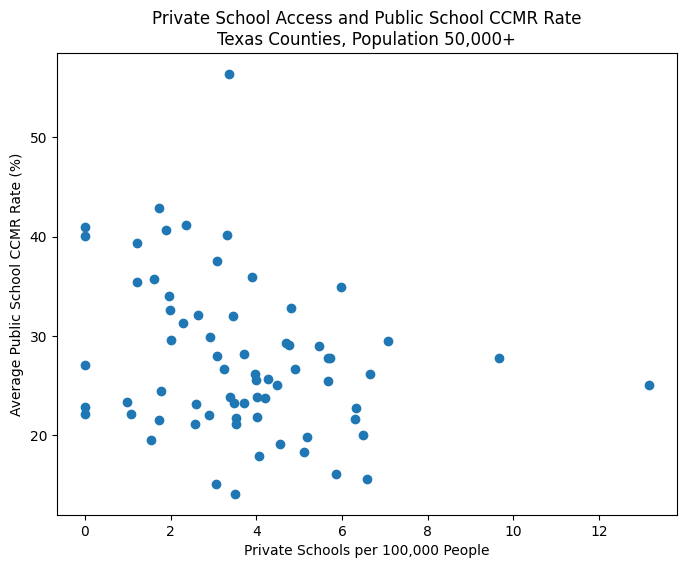

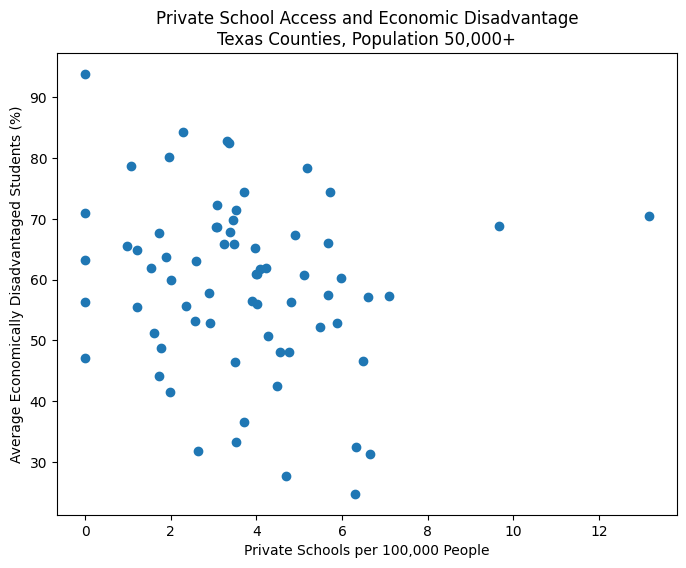

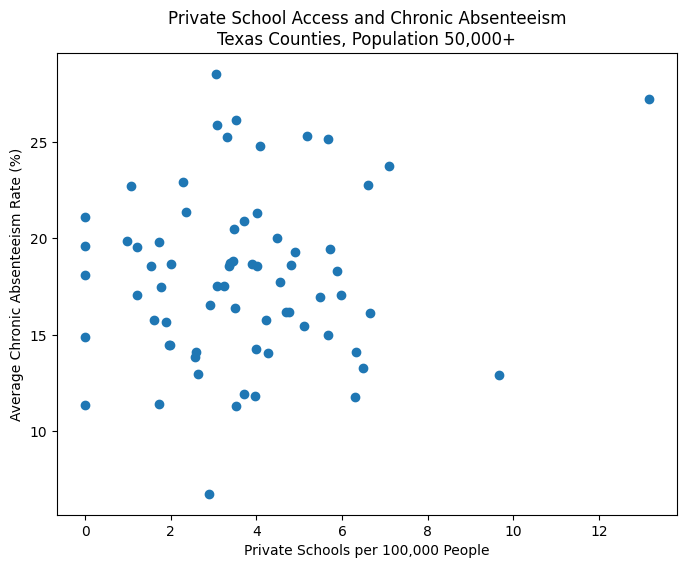

Saved Version 2 charts.


In [31]:
# Version 2 visualizations

os.makedirs(base + "/charts", exist_ok=True)

# 1. Private school access vs CCMR rate
plt.figure(figsize=(8, 6))
plt.scatter(
    larger_v2["private_schools_per_100k"],
    larger_v2["avg_ccmr_rate"]
)
plt.xlabel("Private Schools per 100,000 People")
plt.ylabel("Average Public School CCMR Rate (%)")
plt.title("Private School Access and Public School CCMR Rate\nTexas Counties, Population 50,000+")
plt.savefig(
    base + "/charts/v2_private_access_vs_ccmr.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 2. Private school access vs economically disadvantaged percentage
plt.figure(figsize=(8, 6))
plt.scatter(
    larger_v2["private_schools_per_100k"],
    larger_v2["avg_econ_disadv_pct"]
)
plt.xlabel("Private Schools per 100,000 People")
plt.ylabel("Average Economically Disadvantaged Students (%)")
plt.title("Private School Access and Economic Disadvantage\nTexas Counties, Population 50,000+")
plt.savefig(
    base + "/charts/v2_private_access_vs_econ_disadv.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 3. Private school access vs chronic absenteeism
plt.figure(figsize=(8, 6))
plt.scatter(
    larger_v2["private_schools_per_100k"],
    larger_v2["avg_chronic_absenteeism_rate"]
)
plt.xlabel("Private Schools per 100,000 People")
plt.ylabel("Average Chronic Absenteeism Rate (%)")
plt.title("Private School Access and Chronic Absenteeism\nTexas Counties, Population 50,000+")
plt.savefig(
    base + "/charts/v2_private_access_vs_chronic_absenteeism.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved Version 2 charts.")

In [32]:
# Version 2 regression: Does private-school access predict public school CCMR?

import statsmodels.api as sm

reg_v2 = larger_v2[[
    "avg_ccmr_rate",
    "private_schools_per_100k",
    "median_income",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "avg_econ_disadv_pct",
    "population"
]].replace([np.inf, -np.inf], np.nan).dropna().copy()

reg_v2["median_income_10k"] = reg_v2["median_income"] / 10000
reg_v2["log_population"] = np.log(reg_v2["population"])

X = reg_v2[[
    "private_schools_per_100k",
    "median_income_10k",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "avg_econ_disadv_pct",
    "log_population"
]]

X = sm.add_constant(X)

y = reg_v2["avg_ccmr_rate"]

ccmr_model = sm.OLS(y, X).fit()

print(ccmr_model.summary())

                            OLS Regression Results                            
Dep. Variable:          avg_ccmr_rate   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     2.433
Date:                Mon, 11 May 2026   Prob (F-statistic):             0.0355
Time:                        00:00:42   Log-Likelihood:                -231.90
No. Observations:                  69   AIC:                             477.8
Df Residuals:                      62   BIC:                             493.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [33]:
# Compare models with and without private-school access

reg_v2 = larger_v2[[
    "avg_ccmr_rate",
    "private_schools_per_100k",
    "median_income",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "avg_econ_disadv_pct",
    "population"
]].replace([np.inf, -np.inf], np.nan).dropna().copy()

reg_v2["median_income_10k"] = reg_v2["median_income"] / 10000
reg_v2["log_population"] = np.log(reg_v2["population"])

# Model 1: controls only
X_controls = reg_v2[[
    "median_income_10k",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "avg_econ_disadv_pct",
    "log_population"
]]

X_controls = sm.add_constant(X_controls)

y = reg_v2["avg_ccmr_rate"]

model_controls = sm.OLS(y, X_controls).fit()

# Model 2: controls + private school access
X_private = reg_v2[[
    "private_schools_per_100k",
    "median_income_10k",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "avg_econ_disadv_pct",
    "log_population"
]]

X_private = sm.add_constant(X_private)

model_private = sm.OLS(y, X_private).fit()

print("Model 1 R-squared, controls only:", round(model_controls.rsquared, 3))
print("Model 2 R-squared, with private access:", round(model_private.rsquared, 3))
print("R-squared increase:", round(model_private.rsquared - model_controls.rsquared, 3))
print("Private school access p-value:", round(model_private.pvalues["private_schools_per_100k"], 3))

Model 1 R-squared, controls only: 0.179
Model 2 R-squared, with private access: 0.191
R-squared increase: 0.012
Private school access p-value: 0.351


In [34]:
# Save Version 2 clean datasets and regression summaries

os.makedirs(base + "/data/clean", exist_ok=True)
os.makedirs(base + "/report", exist_ok=True)

tea_district.to_csv(
    base + "/data/clean/tea_district_public_outcomes_clean.csv",
    index=False
)

tea_county.to_csv(
    base + "/data/clean/tea_county_public_outcomes_clean.csv",
    index=False
)

final_v2.to_csv(
    base + "/data/clean/final_education_opportunity_v2_dataset.csv",
    index=False
)

with open(base + "/report/v2_ccmr_regression_summary.txt", "w") as f:
    f.write(ccmr_model.summary().as_text())

v2_summary = f"""# Version 2 Results Summary

## Expanded Research Question

How is private-school access related to public-school outcomes in Texas counties, after accounting for income, poverty, adult education level, economic disadvantage, and population?

## New Data Added

This version adds Texas Academic Performance Reports (TAPR) district-level public-school outcome data. District-level data was aggregated to the county level using student-count weighted averages.

## Public School Outcome Variables

- Economically disadvantaged student percentage
- Attendance rate
- Chronic absenteeism rate
- CCMR rate
- Graduation rate

## Correlation Results

Among Texas counties with populations above 50,000:

- Private-school access vs economically disadvantaged percentage: {corr_private_econ:.3f}
- Private-school access vs attendance rate: {corr_private_attendance:.3f}
- Private-school access vs chronic absenteeism rate: {corr_private_chronic:.3f}
- Private-school access vs CCMR rate: {corr_private_ccmr:.3f}
- Private-school access vs graduation rate: {corr_private_grad:.3f}

## Regression Result

A regression model was used to test whether private-school access predicted public-school CCMR rate after controlling for median income, poverty rate, adult education level, economic disadvantage, and population.

- Controls-only model R-squared: {model_controls.rsquared:.3f}
- Model with private-school access R-squared: {model_private.rsquared:.3f}
- R-squared increase from adding private-school access: {(model_private.rsquared - model_controls.rsquared):.3f}
- Private-school access p-value: {model_private.pvalues["private_schools_per_100k"]:.3f}

## Main Version 2 Finding

Private-school access did not meaningfully improve the model's ability to explain public-school CCMR rates. After accounting for local socioeconomic and educational factors, private-school access was not a statistically significant predictor of public-school CCMR rate.

## Interpretation

The results suggest that private-school access and public-school outcomes should not be treated as simple opposites. Counties with more private-school access do not necessarily have stronger or weaker public-school outcomes at the county level.

## Limitations

This analysis is correlational, not causal. County-level averages can hide differences within counties, and public-school outcomes may be influenced by district funding, school quality, transportation, family choices, urbanization, and other local factors not included in this model.
"""

with open(base + "/report/v2_results_summary.md", "w") as f:
    f.write(v2_summary)

print("Saved Version 2 clean datasets and summaries.")

Saved Version 2 clean datasets and summaries.


In [35]:
print(os.listdir(base + "/data/clean"))
print(os.listdir(base + "/report"))

['private_schools_texas_clean.csv', 'private_schools_by_county.csv', 'census_texas_county_clean.csv', 'private_census_county_dataset.csv', 'all_texas_counties_private_census_dataset.csv', 'tea_district_public_outcomes_clean.csv', 'tea_county_public_outcomes_clean.csv', 'final_education_opportunity_v2_dataset.csv']
['results_summary.md', 'regression_summary.txt', 'final_report.md', 'v2_ccmr_regression_summary.txt', 'v2_results_summary.md']


In [36]:
import os
import shutil

v2_upload_dir = base + "/github_v2_upload"

# Remove old upload folder if it exists
if os.path.exists(v2_upload_dir):
    shutil.rmtree(v2_upload_dir)

# Create folders
os.makedirs(v2_upload_dir + "/data/clean", exist_ok=True)
os.makedirs(v2_upload_dir + "/report", exist_ok=True)
os.makedirs(v2_upload_dir + "/charts", exist_ok=True)

# Copy Version 2 clean data
v2_data_files = [
    "tea_district_public_outcomes_clean.csv",
    "tea_county_public_outcomes_clean.csv",
    "final_education_opportunity_v2_dataset.csv"
]

for file in v2_data_files:
    shutil.copy(
        base + "/data/clean/" + file,
        v2_upload_dir + "/data/clean/" + file
    )

# Copy Version 2 report files
v2_report_files = [
    "v2_ccmr_regression_summary.txt",
    "v2_results_summary.md"
]

for file in v2_report_files:
    shutil.copy(
        base + "/report/" + file,
        v2_upload_dir + "/report/" + file
    )

# Copy Version 2 charts
v2_chart_files = [
    "v2_private_access_vs_ccmr.png",
    "v2_private_access_vs_econ_disadv.png",
    "v2_private_access_vs_chronic_absenteeism.png"
]

for file in v2_chart_files:
    shutil.copy(
        base + "/charts/" + file,
        v2_upload_dir + "/charts/" + file
    )

# Create zip
shutil.make_archive(base + "/github_v2_upload", "zip", v2_upload_dir)

print("Created github_v2_upload.zip")

Created github_v2_upload.zip


In [37]:
print(os.listdir(v2_upload_dir))
print(os.listdir(v2_upload_dir + "/data/clean"))
print(os.listdir(v2_upload_dir + "/report"))
print(os.listdir(v2_upload_dir + "/charts"))

['data', 'report', 'charts']
['tea_district_public_outcomes_clean.csv', 'tea_county_public_outcomes_clean.csv', 'final_education_opportunity_v2_dataset.csv']
['v2_ccmr_regression_summary.txt', 'v2_results_summary.md']
['v2_private_access_vs_ccmr.png', 'v2_private_access_vs_econ_disadv.png', 'v2_private_access_vs_chronic_absenteeism.png']
